# nb02 · 参数集与放电倍率（C-rate）

本篇目标：

1. 查看 PyBaMM 内置**参数集**，选定 `Chen2020`（LG M50）为基准。
2. 修改关键参数（标称容量、初始 SOC）并观察影响。
3. 扫描多个 **C-rate**（0.5C / 1C / 2C / 3C），展示「放电倍率越大、可放出容量越小」。
4. 用 `Experiment` 表达「放到截止电压」，对比恒时长 vs 截止条件两种求解方式。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pybamm

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
print("PyBaMM 版本:", pybamm.__version__)

PyBaMM 版本: 26.6.1.1


## 1. 内置参数集

PyBaMM 自带多套来自文献的参数集，涵盖不同化学体系（NMC、LFP 等）。`Chen2020` 对应 LG M50 圆柱电芯，数据完整、文献常用。

In [2]:
print("可用参数集:")
for name in sorted(pybamm.parameter_sets):
    print("  -", name)

param = pybamm.ParameterValues("Chen2020")
print("\n基准参数集: Chen2020")
print("标称容量 [A.h]:", param["Nominal cell capacity [A.h]"])
print("上/下截止电压 [V]:", param["Upper voltage cut-off [V]"], "/", param["Lower voltage cut-off [V]"])

可用参数集:
  - Ai2020
  - Chayambuka2022
  - Chen2020
  - Chen2020_composite
  - ECM_Example
  - Ecker2015
  - Ecker2015_graphite_halfcell
  - MSMR_Example
  - Marquis2019
  - Mohtat2020
  - NCA_Kim2011
  - OKane2022
  - OKane2022_graphite_SiOx_halfcell
  - ORegan2022
  - Prada2013
  - Ramadass2004
  - Sulzer2019
  - Xu2019

基准参数集: Chen2020
标称容量 [A.h]: 5.0
上/下截止电压 [V]: 4.2 / 2.5


## 2. 修改参数：初始 SOC 的影响

通过 `Simulation(..., initial_soc=...)` 设定不同初始荷电状态，观察起始电压与放电时长变化。

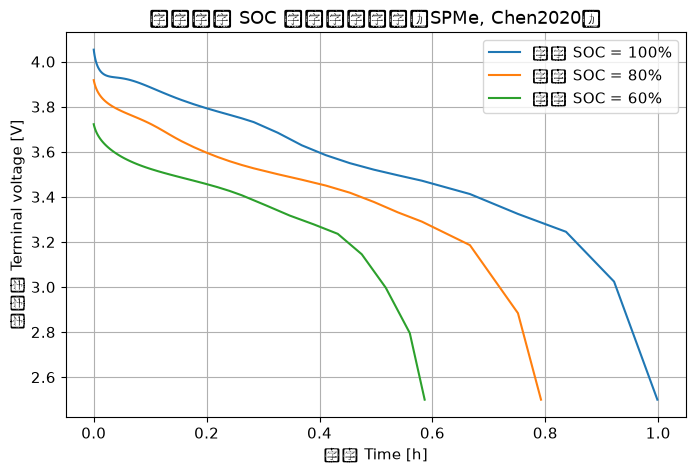

In [3]:
model = pybamm.lithium_ion.SPMe()

for soc in [1.0, 0.8, 0.6]:
    sim = pybamm.Simulation(model, parameter_values=param)
    sol = sim.solve([0, 3600], initial_soc=soc)
    plt.plot(sol["Time [s]"].entries / 3600,
             sol["Terminal voltage [V]"].entries,
             label=f"初始 SOC = {soc:.0%}")
plt.xlabel("时间 Time [h]")
plt.ylabel("端电压 Terminal voltage [V]")
plt.title("不同初始 SOC 下的放电曲线（SPMe, Chen2020）")
plt.legend()
plt.show()

## 3. C-rate 扫描

用 `Experiment` 描述「以 xC 恒流放电直到下截止电压」。倍率越高，极化越大、可放出容量越少。
横轴用**已放出容量 [A.h]** 更能体现容量损失。

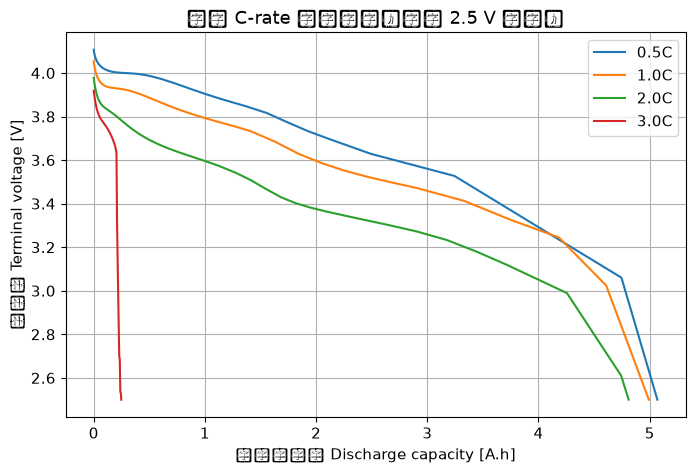

各倍率放出容量 [A.h]:
  0.5C -> 5.069
  1.0C -> 4.992
  2.0C -> 4.811
  3.0C -> 0.247


In [4]:
c_rates = [0.5, 1.0, 2.0, 3.0]
discharged_capacity = {}

for c in c_rates:
    experiment = pybamm.Experiment([f"Discharge at {c}C until 2.5 V"])
    sim = pybamm.Simulation(model, parameter_values=param, experiment=experiment)
    sol = sim.solve(initial_soc=1.0)
    cap = sol["Discharge capacity [A.h]"].entries
    V = sol["Terminal voltage [V]"].entries
    discharged_capacity[c] = cap[-1]
    plt.plot(cap, V, label=f"{c}C")

plt.xlabel("已放出容量 Discharge capacity [A.h]")
plt.ylabel("端电压 Terminal voltage [V]")
plt.title("不同 C-rate 放电曲线（放到 2.5 V 截止）")
plt.legend()
plt.show()

print("各倍率放出容量 [A.h]:")
for c in c_rates:
    print(f"  {c}C -> {discharged_capacity[c]:.3f}")

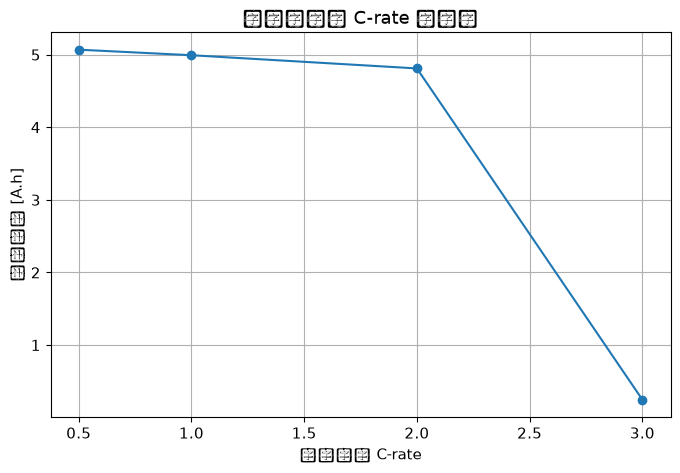

校验通过：放出容量随 C-rate 单调递减。


In [5]:
# 容量-倍率关系：倍率越大，放出容量单调减小
plt.plot(c_rates, [discharged_capacity[c] for c in c_rates], "o-")
plt.xlabel("放电倍率 C-rate")
plt.ylabel("放出容量 [A.h]")
plt.title("放出容量随 C-rate 的变化")
plt.show()

caps = [discharged_capacity[c] for c in c_rates]
assert all(x >= y - 1e-6 for x, y in zip(caps, caps[1:])), "预期：C-rate 越大放出容量越小"
print("校验通过：放出容量随 C-rate 单调递减。")

## 4. 恒时长 vs 截止条件

- `sim.solve([0, T])`：求解固定时长，可能没放到底、也可能放过了。
- `Experiment(["Discharge ... until 2.5 V"])`：自动在到达截止电压时停止，更贴近真实测试。

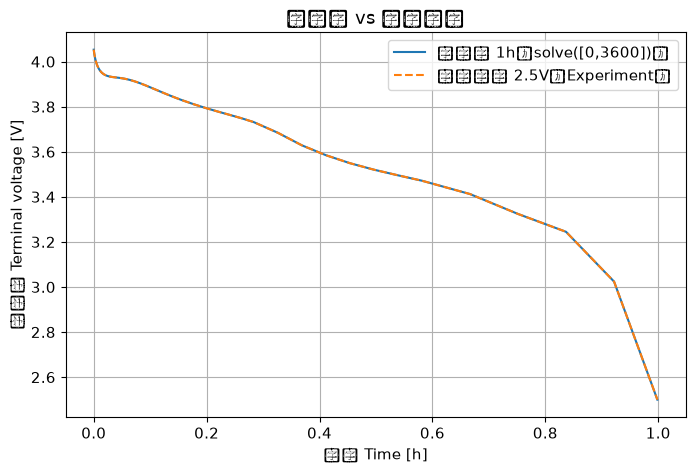

In [6]:
# 恒时长：固定 1 小时
sim_fixed = pybamm.Simulation(model, parameter_values=param)
sol_fixed = sim_fixed.solve([0, 3600], initial_soc=1.0)

# 截止条件：放到 2.5 V
sim_exp = pybamm.Simulation(model, parameter_values=param,
                            experiment=pybamm.Experiment(["Discharge at 1C until 2.5 V"]))
sol_exp = sim_exp.solve(initial_soc=1.0)

plt.plot(sol_fixed["Time [s]"].entries / 3600, sol_fixed["Terminal voltage [V]"].entries,
         label="恒时长 1h（solve([0,3600])）")
plt.plot(sol_exp["Time [s]"].entries / 3600, sol_exp["Terminal voltage [V]"].entries,
         "--", label="截止电压 2.5V（Experiment）")
plt.xlabel("时间 Time [h]")
plt.ylabel("端电压 Terminal voltage [V]")
plt.title("恒时长 vs 截止条件")
plt.legend()
plt.show()

## 小结

- 用 `pybamm.ParameterValues("Chen2020")` 载入参数集，可通过 `param.update({...})` 或 `initial_soc=` 改参。
- C-rate 越高，极化越强，**放出容量单调减小**——这是电池倍率特性的核心现象。
- `Experiment("... until X V")` 让仿真自动在截止电压停止，比固定时长更贴近真实测试。
- 下一篇 `nb03` 进入**动态工况 / drive cycle**。